# Group Component 1:

## Preliminary Changes to Data:

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import RepeatedStratifiedKFold
import os

### Pre-processing based on stage 1

In [4]:
warnings.simplefilter("ignore", FutureWarning)
pd.options.display.float_format = '{:.2f}'.format
df = pd.read_csv("Group17_FinalCleanData.csv")

### Pre-processing in stage 2

#### Unbalanced BMI: Minimum value normalization + clip

In [8]:
# create a new column 'bmi_group' based on the BMI values
groups = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
# print(df['bmi_group'].value_counts())


# compute the inverse of the counts
total = sum(groups.value_counts())
weights_inverse = {k: total/v for k, v in groups.value_counts().items()}

# comput the minimun normalized weight + clip
min_w = min(weights_inverse.values())
# clip the weights to a maximum of 10
weights_clipped_5 = {k: min(v / min_w, 5) for k, v in weights_inverse.items()}
weights_clipped_10 = {k: min(v / min_w, 10) for k, v in weights_inverse.items()}
weights_clipped_20 = {k: min(v / min_w, 20) for k, v in weights_inverse.items()}


df['bmi_group_5'] = groups.map(weights_clipped_5)
df['bmi_group_10'] = groups.map(weights_clipped_10)
df['bmi_group_20'] = groups.map(weights_clipped_20)

df.head()

,BMI,Smoker,HeartDiseaseorAttack,GeneralHealth,Mental (days),Sex,Age,Education,Income,Diabetes,BloodPressure,Cholesterol,Alcoholic,bmi_group_5,bmi_group_10,bmi_group_20
0,40.00,No,No,Very Good,10.81,Female,63.00,High school graduate,73106,No,Yes,Yes,No,1.66,1.66,1.66
1,25.00,Yes,No,Good,6.90,Female,54.00,College graduate,22322,No,No,No,No,1.82,1.82,1.82
2,33.58,No,No,Poor,30.00,Male,50.81,High school graduate,29097,No,Yes,Yes,No,1.66,1.66,1.66
3,27.00,Yes,No,Good,13.23,Male,74.00,Some high school,55498,No,Yes,No,No,1.00,1.00,1.00
4,24.00,Yes,No,Very Good,9.71,Female,62.08,Some college,15629,No,Yes,No,No,1.82,1.82,1.82


#### Class Imbalance Checking

In [11]:
# Check class distribution
counts = df['Diabetes'].value_counts()
print("The number of positive and negative samples:")
print(counts)

props = df['Diabetes'].value_counts(normalize=True)
print("\nPositive and negative sample ratio:")
print(props)

The number of positive and negative samples:
Diabetes
No          170357
Diabetes     28220
Name: count, dtype: int64

Positive and negative sample ratio:
Diabetes
No         0.86
Diabetes   0.14
Name: proportion, dtype: float64


## Data split for train/validation/test sets:

In [14]:
# Cross-validation
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# StratifiedKFold: stratified k-fold cross-validation
# random_state = 42: for reproducibility
# n_splits=5: 5-fold cross-validation
# n_repeats=3: repeat the cross-validation 3 times
skf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
output_dir = './data division/train&test/'
os.makedirs(output_dir, exist_ok=True)

for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    repeat = i // 5 + 1
    fold   = i % 5 + 1   

    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

    train_path = os.path.join(output_dir, f'train_repeat{repeat}_fold{fold}.csv')
    test_path  = os.path.join(output_dir, f'test_repeat{repeat}_fold{fold}.csv')

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path,  index=False)

    print(f'Repeat {repeat}, Fold {fold} have been saved:')
    print(f'  · {train_path} （train set，{train_df.shape[0]} rows）')
    print(f'  · {test_path}  （test set，{test_df.shape[0]} rows）\n')

df.round(2).to_csv('./data division/new0.csv', index=False)

Repeat 1, Fold 1 have been saved:
  · ./data division/train&test/train_repeat1_fold1.csv （train set，158861 rows）
  · ./data division/train&test/test_repeat1_fold1.csv  （test set，39716 rows）

Repeat 1, Fold 2 have been saved:
  · ./data division/train&test/train_repeat1_fold2.csv （train set，158861 rows）
  · ./data division/train&test/test_repeat1_fold2.csv  （test set，39716 rows）

Repeat 1, Fold 3 have been saved:
  · ./data division/train&test/train_repeat1_fold3.csv （train set，158862 rows）
  · ./data division/train&test/test_repeat1_fold3.csv  （test set，39715 rows）

Repeat 1, Fold 4 have been saved:
  · ./data division/train&test/train_repeat1_fold4.csv （train set，158862 rows）
  · ./data division/train&test/test_repeat1_fold4.csv  （test set，39715 rows）

Repeat 1, Fold 5 have been saved:
  · ./data division/train&test/train_repeat1_fold5.csv （train set，158862 rows）
  · ./data division/train&test/test_repeat1_fold5.csv  （test set，39715 rows）

Repeat 2, Fold 1 have been saved:
  · ./data 

# ======== End of Group Component 1 =========

# Individual Component:

## Model Name: LightGBM&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Unikey: yzan0977

### Data Pre-processing:

In [16]:
import ipywidgets
import pandas as pd
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score, average_precision_score,roc_curve, auc, precision_recall_curve, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler, LabelBinarizer
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from sklearn.model_selection import ParameterGrid, cross_val_score
import optuna
from IPython.display import display, HTML, clear_output
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from lightgbm.callback import record_evaluation


optuna.logging.set_verbosity(optuna.logging.WARNING)

y_col = 'Diabetes'
fold_dir = './data division/train&test/'
feature_encoder = OrdinalEncoder()
label_encoder   = LabelBinarizer(pos_label=1, neg_label=0)
label_mapping = {'Diabetes': 1, 'No': 0}
global_threshold=0.3164030718232192
#global_threshold=0.2420292222249854

fix_params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'n_estimators': 800,           # Maximum number of iterations
    'random_state': 42,
    'verbose': -1,
    'bagging_freq': 5,              # Samples are collected every five rounds
    'min_data_in_leaf': 50,         # The minimum number of samples on the leaves
    'lambda_l1': 0.1,               # L1 regularization
    'lambda_l2': 0.2,               # L2 regularization
} 
origin_params ={
    'learning_rate': 0.01,          # Low learning rate
    'num_leaves': 31,               # Limit the number of leaves
    'max_depth': 5,                 # Limit tree depth
    'feature_fraction': 0.8,        # Feature subsampling
    'bagging_fraction': 0.8,        # Sample subsampling
    
}
"""
sta_best_params={
    'learning_rate': 0.05,          # Low learning rate
    'num_leaves': 31,               # Limit the number of leaves
    'max_depth': 7,                 # Limit tree depth
    'feature_fraction': 0.6,        # Feature subsampling
    'bagging_fraction': 0.8,        # Sample subsampling
    
}
"""
sta_best_params={
    'learning_rate': 0.010143560655420285,          # Low learning rate
    'num_leaves': 125,               # Limit the number of leaves
    'max_depth': 7,                 # Limit tree depth
    'feature_fraction': 0.8706834599267687,        # Feature subsampling
    'bagging_fraction': 0.8022617480317952,        # Sample subsampling
    
}


num_cols = ['BMI', 'Mental (days)', 'Age', 'Income']
categorical_cols = ['Smoker', 'HeartDiseaseorAttack', 'GeneralHealth','Sex', 'Education', 'BloodPressure','Cholesterol', 'Alcoholic']

num_pipeline = Pipeline([
    ('scaler', StandardScaler()),               
    ('pca',    PCA(n_components=0.95))           
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),           
    ('cat', feature_encoder, categorical_cols)        
])

### Initial Model Development and Evaluation:

In [ ]:
def use_lightgbm(data_dir: str=fold_dir,label_col: str = y_col,n_folds: int = 15, use_best_param: bool = True):
   
    all_acc, all_auc, all_f1, all_prauc = [], [], [], []

    # pilot
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    precisions_interp = []

    all_val_trues = []
    all_val_probs = []
    fold_reports = []
    for i in range(1, n_folds + 1):
        repeat = (i-1) // 5 + 1
        fold   = (i-1) % 5  +1
        #Load the training/test file of this fold 
        train_path = f"{data_dir}train_repeat{repeat}_fold{fold}.csv"
        test_path  = f"{data_dir}test_repeat{repeat}_fold{fold}.csv"
        train_df   = pd.read_csv(train_path)
        test_df    = pd.read_csv(test_path)

        #Feature/label separation
        x_train = train_df.drop(columns=[label_col])
        y_train = train_df[label_col]
        x_test  = test_df.drop(columns=[label_col])
        y_test  = test_df[label_col]

        x_train_proc = preprocessor.fit_transform(x_train) 
        x_test_proc  = preprocessor.transform(x_test)

        y_train_enc = y_train.map(label_mapping).astype(int)
        y_test_enc  = y_test.map(label_mapping).astype(int)
        
        #x_object_cols = x_train.select_dtypes(include='object').columns.tolist()
        #x_train[x_object_cols] = feature_encoder.fit_transform(x_train[x_object_cols])
        #x_test[x_object_cols] = feature_encoder.transform(x_test[x_object_cols])
        #le = LabelEncoder()
        #y_train = label_encoder.fit_transform(y_train)
        #y_test  = label_encoder.transform(y_test)
        

        #Initialize and train the model
        train_dy_params={}
        if use_best_param:
            train_dy_params=sta_best_params
        else:
            train_dy_params=origin_params
            
        x_tr, x_val, y_tr, y_val = train_test_split(
            x_train_proc, y_train_enc,
            test_size=0.2,
            stratify=y_train_enc,
            random_state=42
        )
        
        neg = (y_tr == 0).sum()
        pos = (y_tr == 1).sum()
        model = LGBMClassifier(**fix_params, **train_dy_params, is_unbalance=False, scale_pos_weight=neg/pos)

        evals_result = {}
        
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_tr, y_tr),(x_val, y_val)],
            eval_metric='auc',
            callbacks=[early_stopping(stopping_rounds=20),log_evaluation(period=0),record_evaluation(evals_result)]
        )
        #model.fit(
            #x_train, y_train,
            #eval_set=[(x_test, y_test)],
            #eval_metric='auc',
            #callbacks=[early_stopping(stopping_rounds=50),log_evaluation(period=0)]
        #)
        y_val_true  = y_val
        y_val_probs = model.predict_proba(x_val)[:, 1]
        all_val_trues.append(y_val_true)
        all_val_probs.append(y_val_probs)
        

        #Predict and evaluate on the test set
        y_pred_prob = model.predict_proba(x_test_proc)[:, 1]
        y_pred = (y_pred_prob >= global_threshold).astype(int)
        
        #y_pred      = model.predict(x_test_proc)
        #y_pred_prob = model.predict_proba(x_test_proc)[:, 1]
        acc = accuracy_score(y_test_enc, y_pred)
        auc = roc_auc_score(y_test_enc, y_pred_prob)
        f1     = f1_score(y_test_enc,  y_pred)                 
        pr_auc = average_precision_score(y_test_enc, y_pred_prob)      

        print(classification_report(y_test_enc, y_pred))
        report_dict =classification_report(y_test_enc, y_pred,output_dict=True)
        fold_reports.append(report_dict)
        
        all_acc.append(acc)
        all_auc.append(auc)
        all_f1.append(f1)                                       
        all_prauc.append(pr_auc) 
        print(f"N_Repeat {repeat}, Fold {fold}: "
          f"ACC={acc:.4f}, "
          f"ROC-AUC={auc:.4f}, "
          f"F1={f1:.4f}, "                                     
          f"PR-AUC={pr_auc:.4f}, "
          f"BestIter={model.best_iteration_}")
        """
        plt.figure(figsize=(6,4))
        plt.plot(
            evals_result['training']['auc'],
            label='train AUC'
        )
        plt.plot(
            evals_result['valid_1']['auc'],
            label='val   AUC'
        )
        plt.axvline(
            model.best_iteration_, linestyle='--',
            label=f'best iter ({model.best_iteration_})'
        )
        plt.xlabel('Boosting Iteration')
        plt.ylabel('AUC')
        plt.title(f'Fold {i} Learning Curve')
        plt.legend()
        plt.show()

        y_prob = model.predict_proba(x_test_proc)[:,1]
        fpr, tpr, _ = roc_curve(y_test_enc, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, color='b',
                 label=f'ROC fold {i} (AUC = {roc_auc:.3f})')
        plt.plot([0,1], [0,1], 'k--', lw=1)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Fold {i} ROC Curve')
        plt.legend(loc='lower right')
        plt.show()
        
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        
        precision, recall, _ = precision_recall_curve(y_test_enc, y_pred_prob)
        pr_auc_val = auc(recall, precision)
        plt.figure(figsize=(6,4))
        plt.plot(recall, precision, color='m',
                 label=f'PR fold {i} (AUC = {pr_auc_val:.3f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Fold {i} Precision–Recall Curve')
        plt.legend(loc='lower left')
        plt.show()

        precisions_interp.append(
            np.interp(mean_fpr, recall[::-1], precision[::-1])[::-1]
        )
        """


    

    """
    plt.figure(figsize=(6,4))
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)
    plt.plot(mean_fpr, mean_tpr, 'b-',
             label=f'Mean ROC (AUC = {mean_auc:.3f})')
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title('Mean ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    plt.figure(figsize=(6,4))
    mean_precision = np.mean(precisions_interp, axis=0)
    mean_pr_auc = auc(mean_fpr, mean_precision)
    plt.plot(mean_fpr, mean_precision, 'm-',
             label=f'Mean PR (AUC = {mean_pr_auc:.3f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Mean Precision–Recall Curve')
    plt.legend(loc='lower left')
    plt.show()
    """
    all_val_trues = np.concatenate(all_val_trues)
    all_val_probs = np.concatenate(all_val_probs)
    precision, recall, thresh = precision_recall_curve(all_val_trues, all_val_probs)
    f1_scores = 2*precision[:-1]*recall[:-1]/(precision[:-1]+recall[:-1]+1e-8)
    best = thresh[f1_scores.argmax()]
    print("Global optimal threshold:", best)

    all_keys = fold_reports[0].keys()
    avg_report = {}
    for key in all_keys:
        if key == 'accuracy':
            avg_report[key] = np.mean([fr[key] for fr in fold_reports])
        else:
            avg_report[key] = {
                metric: np.mean([fr[key][metric] for fr in fold_reports])
                for metric in fold_reports[0][key].keys()
            }
    avg_df = pd.DataFrame(avg_report).T
    avg_df = avg_df[['precision','recall','f1-score','support']] if 'precision' in avg_df.columns else avg_df
    print("\n===== Average Classification Report =====")
    print(avg_df.to_string(float_format="%.3f"))

    mean_acc = sum(all_acc) / n_folds
    mean_auc = sum(all_auc) / n_folds
    mean_f1 = sum(all_f1)    / n_folds
    mean_prauc=sum(all_prauc) / n_folds
    print(f"\nMean Accuracy over {n_folds} folds: {mean_acc:.4f}")
    print(f"Mean ROC-AUC     over {n_folds} folds: {mean_auc:.4f}")
    print(f"Mean F1    over {n_folds} folds: {mean_f1:.4f}")
    print(f"Mean PR-AUC  over {n_folds} folds: {mean_prauc:.4f}")

### Model Optimisation:

I used grid search and Bayesian optimization respectively to find the optimal hyperparameters. The remaining optimizations, such as the early stop strategy, dynamic weights and thresholds, were completed when implementing the model.

In [18]:
def tuning_by_grid_search(full_data_path: str,cv: int =5)->dict:
    param_grid = {
        'clf__learning_rate':   [0.01, 0.05],
        'clf__num_leaves':      [31, 63],
        'clf__max_depth':       [5, 7],
        'clf__feature_fraction':[0.6, 0.8],
        'clf__bagging_fraction':[0.6, 0.8],
    }
    
    data = pd.read_csv(full_data_path)
    x = data.drop(columns=[y_col])
    y = data[y_col]
    y = y.map(label_mapping).astype(int)
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', LGBMClassifier(**fix_params))
    ])
    best_score = -float('inf')
    best_params = None
    for params in tqdm(
        list(ParameterGrid(param_grid)),
        desc="Grid Search",
        unit="combo",
        ascii=True
    ):
        pipe.set_params(**params)
        scores = cross_val_score(
            pipe, x, y,
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1
        )
        mean_score = scores.mean()
        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    print(f"Global tuning → best params: {best_params}, best CV AUC: {best_score:.4f}")
    return best_params

def tuning_by_bayes(full_data_path: str,cv: int =5, n_trials: int = 50, random_state: int = 42)->dict:
    data = pd.read_csv(full_data_path)
    x = data.drop(columns=[y_col])
    y = data[y_col]
    y = y.map(label_mapping).astype(int)
    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', LGBMClassifier(**fix_params))
    ])
    def objective(trial):
        # suggest hyperparameters
        params = {
            'clf__learning_rate':   trial.suggest_float('learning_rate', 1e-3, 1e-1,log=True),
            'clf__num_leaves':      trial.suggest_int('num_leaves', 31, 127),
            'clf__max_depth':       trial.suggest_int('max_depth', 5, 12),
            'clf__feature_fraction':trial.suggest_float('feature_fraction', 0.6, 1.0),
            'clf__bagging_fraction':trial.suggest_float('bagging_fraction', 0.6, 1.0),
            #'lambda_l1':       trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
            #'lambda_l2':       trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        }
        # merge with fixed params
        pipe.set_params(**params)
        # evaluate with CV
        score = cross_val_score(
            pipe, x, y,
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1
        ).mean()
        return score
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=random_state)
    )
    # Can't use tqdm
    def _html_callback(study, trial):
        clear_output(wait=True)
        done = len(study.trials)
        display(HTML(f"""
            <div style="font-family: monospace;">
              Trial {done} / {n_trials}
              <progress value="{done}" max="{n_trials}" style="width: 100%;"></progress>
            </div>
        """))
    clear_output(wait=True)
    display(HTML(f"""
      <div style="font-family: monospace;">
        Trial 0 / {n_trials}
        <progress value="0" max="{n_trials}" style="width: 100%;"></progress>
      </div>
    """))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, callbacks=[_html_callback])
    clear_output(wait=True)

    print("Best CV AUC:", study.best_value)
    print("Best params:", study.best_params)
    return study.best_params

#### Run Grid Search

In [20]:
tuning_by_grid_search("./data division/new0.csv",5) #It takes a very long time to find the best params

Grid Search: 100%|##################################################################| 32/32 [42:14<00:00, 79.21s/combo]

Global tuning → best params: {'clf__bagging_fraction': 0.6, 'clf__feature_fraction': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 7, 'clf__num_leaves': 63}, best CV AUC: 0.8489


{'clf__bagging_fraction': 0.6,
 'clf__feature_fraction': 0.8,
 'clf__learning_rate': 0.01,
 'clf__max_depth': 7,
 'clf__num_leaves': 63}

#### Run Bayesian optimization

In [74]:
tuning_by_bayes("./data division/new0.csv",5,100,42) #It takes a very long time to find the best params

Best CV AUC: 0.8508424975034611
Best params: {'learning_rate': 0.010143560655420285, 'num_leaves': 125, 'max_depth': 10, 'feature_fraction': 0.8706834599267687, 'bagging_fraction': 0.8022617480317952}


{'learning_rate': 0.010143560655420285,
 'num_leaves': 125,
 'max_depth': 10,
 'feature_fraction': 0.8706834599267687,
 'bagging_fraction': 0.8022617480317952}

### Model Results:

#### Run with best hyperparameters:

In [11]:
use_lightgbm(fold_dir,y_col,15,True)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[42]	training's auc: 0.851719	training's binary_logloss: 0.368812	valid_1's auc: 0.841866	valid_1's binary_logloss: 0.371102
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     34072
           1       0.43      0.61      0.50      5644

    accuracy                           0.83     39716
   macro avg       0.68      0.74      0.70     39716
weighted avg       0.86      0.83      0.84     39716

N_Repeat 1, Fold 1: ACC=0.8290, ROC-AUC=0.8416, F1=0.5021, PR-AUC=0.4590, BestIter=42
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[42]	training's auc: 0.850241	training's binary_logloss: 0.369399	valid_1's auc: 0.845279	valid_1's binary_logloss: 0.370266
              precision    recall  f1-score   support

           0       0.93      0.86      0.89     34072
           1       0.42      0.62   

#### Run with origin hyperparameters:

In [13]:
use_lightgbm(fold_dir,y_col,15,False)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[38]	training's auc: 0.838464	training's binary_logloss: 0.375069	valid_1's auc: 0.834854	valid_1's binary_logloss: 0.375828
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     34072
           1       0.45      0.52      0.48      5644

    accuracy                           0.84     39716
   macro avg       0.68      0.71      0.69     39716
weighted avg       0.85      0.84      0.85     39716

N_Repeat 1, Fold 1: ACC=0.8415, ROC-AUC=0.8347, F1=0.4804, PR-AUC=0.4422, BestIter=38
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[38]	training's auc: 0.837325	training's binary_logloss: 0.375475	valid_1's auc: 0.839885	valid_1's binary_logloss: 0.37476
              precision    recall  f1-score   support

           0       0.92      0.89      0.91     34072
           1       0.45      0.52    

### Algorithm pseudocode

LightGBM

Input: D={(xᵢ,yᵢ)}, T, η, λ, γ, num_leaves, max_depth

F ← 0
for t = 1 to T:
  compute gᵢ ← ∂L/∂F(xᵢ), hᵢ ← ∂²L/∂F(xᵢ)
  (opt) apply GOSS/EFB to {g,h}
  build tree f by leaf-wise splits on histograms until num_leaves/max_depth
  set each leaf weight w ← –Σg/ (Σh+λ)
  F ← F + η·f
return F


## =============== End of LightGBM yzan0977 ===============

## Model Name: CatBoost&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Unikey: kwan0569

In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from catboost import CatBoostClassifier

train_df = pd.read_csv("./data division/train&test/train_repeat1_fold1.csv")
test_df = pd.read_csv("./data division/train&test/test_repeat1_fold1.csv")

# Clean the target column and keep only "No" and "Diabetes"
train_df = train_df[train_df['Diabetes'].isin(['No', 'Diabetes'])]
test_df = test_df[test_df['Diabetes'].isin(['No', 'Diabetes'])]

# Convert to 0 and 1
train_df['Diabetes'] = train_df['Diabetes'].map({'No': 0, 'Diabetes': 1}).astype(int)
test_df['Diabetes'] = test_df['Diabetes'].map({'No': 0, 'Diabetes': 1}).astype(int)

# Prepare the feature column (Remove redundant features)
drop_cols = ['Diabetes', 'bmi_group_5', 'bmi_group_10', 'bmi_group_20']
features = [col for col in train_df.columns if col not in drop_cols]

X_train = train_df[features]
y_train = train_df['Diabetes']
X_test = test_df[features]
y_test = test_df['Diabetes']

# Automatically identify category features
cat_features = X_train.select_dtypes(include='object').columns.tolist()

# Build and train the model
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    class_weights=[1, 6],  # Dealing with category imbalance
    verbose=0,
    random_state=42
)
model.fit(X_train, y_train, cat_features=cat_features)

# Model Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation Indicators
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print(f"F1-score   : {f1:.4f}")
print(f"ROC-AUC    : {roc:.4f}")
print(f"PR-AUC     : {pr:.4f}")

F1-score   : 0.5110
ROC-AUC    : 0.8773
PR-AUC     : 0.5604


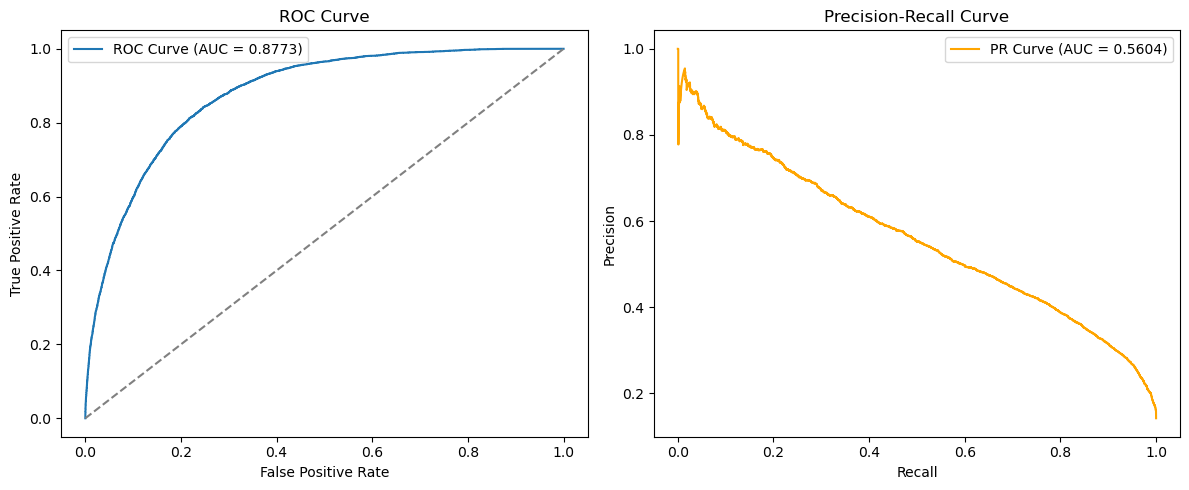

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

train_df = pd.read_csv("./data division/train&test/train_repeat1_fold1.csv")
test_df = pd.read_csv("./data division/train&test/test_repeat1_fold1.csv")

train_df = train_df[train_df['Diabetes'].isin(['No', 'Diabetes'])]
test_df = test_df[test_df['Diabetes'].isin(['No', 'Diabetes'])]

train_df['Diabetes'] = train_df['Diabetes'].map({'No': 0, 'Diabetes': 1}).astype(int)
test_df['Diabetes'] = test_df['Diabetes'].map({'No': 0, 'Diabetes': 1}).astype(int)

drop_cols = ['Diabetes', 'bmi_group_5', 'bmi_group_10', 'bmi_group_20']
features = [col for col in train_df.columns if col not in drop_cols]

X_train = train_df[features]
y_train = train_df['Diabetes']
X_test = test_df[features]
y_test = test_df['Diabetes']

cat_features = X_train.select_dtypes(include='object').columns.tolist()

model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    class_weights=[1, 6],
    verbose=0,
    random_state=42
)
model.fit(X_train, y_train, cat_features=cat_features)

# Predicted Probability
y_prob = model.predict_proba(X_test)[:, 1]

# ROC and PR curve data
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Drawing
plt.figure(figsize=(12, 5))

# ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# PR
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f"PR Curve (AUC = {average_precision_score(y_test, y_prob):.4f})", color='orange')
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# Identify categorical features
categorical_features_list = X_train.select_dtypes(include='object').columns.tolist()

# Initialize the CatBoost model
cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42,
    class_weights=[1, 6],
    cat_features=categorical_features_list 
)

# Grid Parameters
param_grid = {
    'iterations': [200, 300],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [3, 5, 7],
}

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
grid = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring='average_precision',  # Metrics in the task
    cv=cv,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best PR-AUC:", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'depth': 8, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Best PR-AUC: 0.5707151408859812


In [11]:
best_model = CatBoostClassifier(
    depth=8,
    iterations=300,
    l2_leaf_reg=3,
    learning_rate=0.1,
    class_weights=[1, 6],
    cat_features=categorical_features_list,
    verbose=0,
    random_state=42
)

best_model.fit(X_train, y_train)


In [13]:
import pandas as pd

results_df = pd.DataFrame(grid.cv_results_)

# Display all rating columns
score_cols = [col for col in results_df.columns if 'mean_test' in col]
results_df[score_cols + ['params']]

,mean_test_score,params
0,0.482656,"{'depth': 4, 'iterations': 200, 'l2_leaf_reg':..."
1,0.509817,"{'depth': 4, 'iterations': 200, 'l2_leaf_reg':..."
2,0.483544,"{'depth': 4, 'iterations': 200, 'l2_leaf_reg':..."
3,0.509682,"{'depth': 4, 'iterations': 200, 'l2_leaf_reg':..."
4,0.483136,"{'depth': 4, 'iterations': 200, 'l2_leaf_reg':..."
5,0.511024,"{'depth': 4, 'iterations': 200, 'l2_leaf_reg':..."
6,0.495941,"{'depth': 4, 'iterations': 300, 'l2_leaf_reg':..."
7,0.529818,"{'depth': 4, 'iterations': 300, 'l2_leaf_reg':..."
8,0.496331,"{'depth': 4, 'iterations': 300, 'l2_leaf_reg':..."
9,0.530425,"{'depth': 4, 'iterations': 300, 'l2_leaf_reg':..."


In [15]:
print(grid.best_estimator_)        # Optimal Model
print(grid.best_params_)           # Optimal Parameter Combination
print(grid.best_score_)            # The Score of the Optimal Model (PR-AUC)

{'depth': 8, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
0.5707151408859812


In [17]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))
print("PR-AUC  :", average_precision_score(y_test, y_prob))

F1-score: 0.5110320284697509
ROC-AUC : 0.877329342091097
PR-AUC  : 0.5604077686859554


In [19]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# Load the test set
test_df = pd.read_csv("./data division/train&test/test_repeat1_fold1.csv")
test_df = test_df[test_df['Diabetes'].isin(['No', 'Diabetes'])]
test_df['Diabetes'] = test_df['Diabetes'].map({'No': 0, 'Diabetes': 1}).astype(int)

X_test = test_df[X_train.columns]
y_test = test_df['Diabetes']

# Prediction
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.96      0.78      0.86     34072
           1       0.38      0.82      0.52      5644

    accuracy                           0.78     39716
   macro avg       0.67      0.80      0.69     39716
weighted avg       0.88      0.78      0.81     39716

ROC-AUC: 0.8801076776132055
PR-AUC : 0.5700249758448088


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_81640\1054956678.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_test_score', y='label', data=top_results, palette="Blues_d")


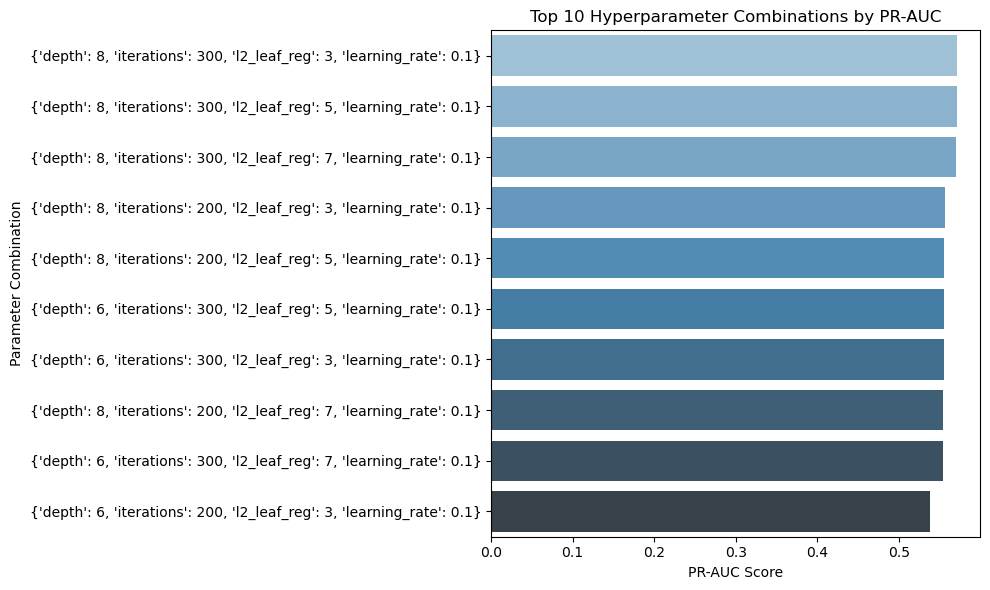

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the result table
results = pd.DataFrame(grid.cv_results_)

# Take PR-AUC and the parameter column
top_results = results[['mean_test_score', 'params']].sort_values(by='mean_test_score', ascending=False).head(10)

# Add a label column (as the Y-axis)
top_results['label'] = top_results['params'].astype(str)

# Drawing
plt.figure(figsize=(10, 6))
sns.barplot(x='mean_test_score', y='label', data=top_results, palette="Blues_d")
plt.title("Top 10 Hyperparameter Combinations by PR-AUC")
plt.xlabel("PR-AUC Score")
plt.ylabel("Parameter Combination")
plt.tight_layout()
plt.show()

Input: training set (X, y), cat_features list

Initialize model F₀(x) = 0

For t = 1 to T (iterations):
    Compute gradient residuals: rᵢ = ∂Loss(yᵢ, Fₜ₋₁(xᵢ))
    
    Estimate target statistics (CTR) for categorical features using ordered boosting
    
    Train a symmetric tree hₜ(x) on residuals
    
    Update model: Fₜ(x) = Fₜ₋₁(x) + η * hₜ(x)

Return final model: F_T(x)


## =============== End of CatBoost kwan0569 ===============

## Model Name: XGBoost&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Unikey: xiwu3008

### Load Libraries

In [1]:
import pandas as pd
import warnings
from sklearn.model_selection import RepeatedStratifiedKFold
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, average_precision_score, precision_recall_curve 
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

## Load dataset based on stage 1

In [2]:
warnings.simplefilter("ignore", FutureWarning)
pd.options.display.float_format = '{:.2f}'.format

df = pd.read_csv("Group17_FinalCleanData.csv")

## Pre-processing in stage 2

#### Unbalanced BMI: Minimum value normalization + clip

In [3]:
# create a new column 'bmi_group' based on the BMI values
groups = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
# print(df['bmi_group'].value_counts())


# compute the inverse of the counts
total = sum(groups.value_counts())
weights_inverse = {k: total/v for k, v in groups.value_counts().items()}

# comput the minimun normalized weight + clip
min_w = min(weights_inverse.values())
# clip the weights to a maximum of 10
weights_clipped_5 = {k: min(v / min_w, 5) for k, v in weights_inverse.items()}
weights_clipped_10 = {k: min(v / min_w, 10) for k, v in weights_inverse.items()}
weights_clipped_20 = {k: min(v / min_w, 20) for k, v in weights_inverse.items()}

# bmi_group_5 = groups.map(weights_clipped_5)
bmi_group_10 = groups.map(weights_clipped_5)
# bmi_group_20 = groups.map(weights_clipped_5)

# df['bmi_group_5'] = bmi_group_5
df['bmi_group_10'] = bmi_group_10
# df['bmi_group_20'] = bmi_group_20

df.head()


,BMI,Smoker,HeartDiseaseorAttack,GeneralHealth,Mental (days),Sex,Age,Education,Income,Diabetes,BloodPressure,Cholesterol,Alcoholic,bmi_group_10
0,40.00,No,No,Very Good,10.81,Female,63.00,High school graduate,73106,No,Yes,Yes,No,1.66
1,25.00,Yes,No,Good,6.90,Female,54.00,College graduate,22322,No,No,No,No,1.82
2,33.58,No,No,Poor,30.00,Male,50.81,High school graduate,29097,No,Yes,Yes,No,1.66
3,27.00,Yes,No,Good,13.23,Male,74.00,Some high school,55498,No,Yes,No,No,1.00
4,24.00,Yes,No,Very Good,9.71,Female,62.08,Some college,15629,No,Yes,No,No,1.82


### Class Imbalance Checking

In [4]:
# Check class distribution
counts = df['Diabetes'].value_counts()
print("The number of positive and negative samples:")
print(counts)

props = df['Diabetes'].value_counts(normalize=True)
print("\nPositive and negative sample ratio:")
print(props)


The number of positive and negative samples:
Diabetes
No          170357
Diabetes     28220
Name: count, dtype: int64

Positive and negative sample ratio:
Diabetes
No         0.86
Diabetes   0.14
Name: proportion, dtype: float64


## Without SMOTE

In [5]:
# copy the original data
df_non_smote = df.copy()

### Orignal BIM

In [6]:
# Convert categorical features to 'pd.Categorical'
df_non_smote['Smoker'] = pd.Categorical(df_non_smote['Smoker'], categories=['No', 'Yes'])
df_non_smote['Sex'] = pd.Categorical(df_non_smote['Sex'], categories=['Male', 'Female'])
df_non_smote['HeartDiseaseorAttack'] = pd.Categorical(df_non_smote['HeartDiseaseorAttack'], categories=['No', 'Yes'])
df_non_smote['BloodPressure'] = pd.Categorical(df_non_smote['BloodPressure'], categories=['No', 'Yes'])
df_non_smote['Cholesterol'] = pd.Categorical(df_non_smote['Cholesterol'], categories=['No', 'Yes'])
df_non_smote['Alcoholic'] = pd.Categorical(df_non_smote['Alcoholic'], categories=['No', 'Yes'])

# Convert ordinal categorical features to 'pd.Categorical' with order
df_non_smote['GeneralHealth'] = pd.Categorical(
    df_non_smote['GeneralHealth'],
    categories=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
    ordered=True
)

df_non_smote['Education'] = pd.Categorical(
    df_non_smote['Education'],
    categories=['Never attended school', 'Elementary',
                'Some high school', 'High school graduate',
                'Some college', 'College graduate'],
    ordered=True
)


In [7]:
# Map target variable：1 -> diabetes (postive)，0 -> no diabetes (negative)
df_non_smote['Diabetes'] = df_non_smote['Diabetes'].map({'No': 0, 'Diabetes': 1})

In [8]:
df_non_smote.head()

,BMI,Smoker,HeartDiseaseorAttack,GeneralHealth,Mental (days),Sex,Age,Education,Income,Diabetes,BloodPressure,Cholesterol,Alcoholic,bmi_group_10
0,40.00,No,No,Very Good,10.81,Female,63.00,High school graduate,73106,0,Yes,Yes,No,1.66
1,25.00,Yes,No,Good,6.90,Female,54.00,College graduate,22322,0,No,No,No,1.82
2,33.58,No,No,Poor,30.00,Male,50.81,High school graduate,29097,0,Yes,Yes,No,1.66
3,27.00,Yes,No,Good,13.23,Male,74.00,Some high school,55498,0,Yes,No,No,1.00
4,24.00,Yes,No,Very Good,9.71,Female,62.08,Some college,15629,0,Yes,No,No,1.82


In [9]:
# Split the data into features (X) and target variable (y)

# original bmi group VS normalized_bmi_weight group
X_bmi_weight = df_non_smote.drop(['Diabetes', 'BMI'], axis=1)

X = df_non_smote.drop(['Diabetes', 'bmi_group_10'], axis=1)

y = df_non_smote['Diabetes']

In [10]:
X.head()

,BMI,Smoker,HeartDiseaseorAttack,GeneralHealth,Mental (days),Sex,Age,Education,Income,BloodPressure,Cholesterol,Alcoholic
0,40.00,No,No,Very Good,10.81,Female,63.00,High school graduate,73106,Yes,Yes,No
1,25.00,Yes,No,Good,6.90,Female,54.00,College graduate,22322,No,No,No
2,33.58,No,No,Poor,30.00,Male,50.81,High school graduate,29097,Yes,Yes,No
3,27.00,Yes,No,Good,13.23,Male,74.00,Some high school,55498,Yes,No,No
4,24.00,Yes,No,Very Good,9.71,Female,62.08,Some college,15629,Yes,No,No


In [11]:
# Split the data into training and testing sets
# Stratified sampling to maintain the same proportion of classes in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
# Create the parameter grid
gbm_param_grid = {
    'eta': [0.01, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [10, 50],
    'colsample_bytree': [0.5, 0.8, 1],
    'subsample': [0.5, 0.8, 1.0]
}

# initialize the xgboost classifier
gbm = xgb.XGBClassifier(enable_categorical=True, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())

# define scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'pr_auc': 'average_precision',
    'precision': 'precision',
    'recall': 'recall'
}

# define cross-validation
# StratifiedKFold: stratified sampling 
# random_state = 42: for reproducibility
# n_splits=5: 5-fold
# n_repeats=2: repeat CV 2 times
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

# Create the GridSearchCV object
grid = GridSearchCV(estimator=gbm, 
                    param_grid=gbm_param_grid, 
                    cv=cv, 
                    scoring=scoring, 
                    verbose=1, # show progress messages
                    refit='pr_auc')  # refit the best model using the 'pr_auc' score)

# # Fit the model on train set
grid.fit(X_train, y_train)

Fitting 10 folds for each of 72 candidates, totalling 720 fits


GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=2, n_splits=5, random_state=42),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.5, 0.8, 1], 'eta': [0.01, 0.1],
                         'max_depth': [3, 5], 'n_estimators': [10, 50],
                         'subsample': [0.5, 0.8, 1.0]},
             refit='pr_auc',
             scoring={'f1': 'f1', 'pr_auc': 'average_precision',
                      'precision': 'precision', 'recall': 'recall',
                      'roc_auc': 'roc_auc'},
             verbose=1)

In [16]:
# print the grid search results
results = pd.DataFrame(grid.cv_results_)

# print([col for col in grid.cv_results_.keys() if 'mean_test' in col])

cols_to_show = ['params',
                'mean_test_roc_auc', 
                'mean_test_f1', 
                # 'mean_test_neg_log_loss', 
                'mean_test_pr_auc', 
                # 'mean_test_accuracy', 
                'mean_test_precision', 
                'mean_test_recall']

results[cols_to_show].sort_values(by='mean_test_pr_auc', ascending=False).head(5)

,params,mean_test_roc_auc,mean_test_f1,mean_test_pr_auc,mean_test_precision,mean_test_recall
46,"{'colsample_bytree': 0.8, 'eta': 0.1, 'max_dep...",0.86,0.49,0.50,0.35,0.81
45,"{'colsample_bytree': 0.8, 'eta': 0.1, 'max_dep...",0.86,0.49,0.50,0.35,0.81
47,"{'colsample_bytree': 0.8, 'eta': 0.1, 'max_dep...",0.86,0.49,0.50,0.35,0.81
70,"{'colsample_bytree': 1, 'eta': 0.1, 'max_depth...",0.86,0.49,0.50,0.35,0.81
69,"{'colsample_bytree': 1, 'eta': 0.1, 'max_depth...",0.86,0.49,0.50,0.35,0.81


In [17]:
# fine the best model
best_model = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_

print("Best parameters:", best_params)
print("Best PR-AUC on training set:", best_score)

# predict on the test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Classification result:\n", classification_report(y_test, y_pred, digits=3))
print("ROC-AUC on test dataset:", roc_auc_score(y_test, y_prob))
print("PR-AUC on test dataset:", average_precision_score(y_test, y_prob))

Best parameters: {'colsample_bytree': 0.8, 'eta': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
Best PR-AUC on training set: 0.5013761038045399
Classification result:
               precision    recall  f1-score   support

           0      0.961     0.756     0.846     34072
           1      0.356     0.815     0.495      5644

    accuracy                          0.764     39716
   macro avg      0.658     0.785     0.671     39716
weighted avg      0.875     0.764     0.796     39716

ROC-AUC on test dataset: 0.8634357456274278
PR-AUC on test dataset: 0.5034964938094634


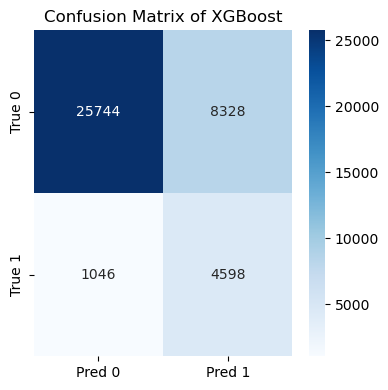

In [18]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.title("Confusion Matrix of XGBoost"); plt.tight_layout()
plt.show()

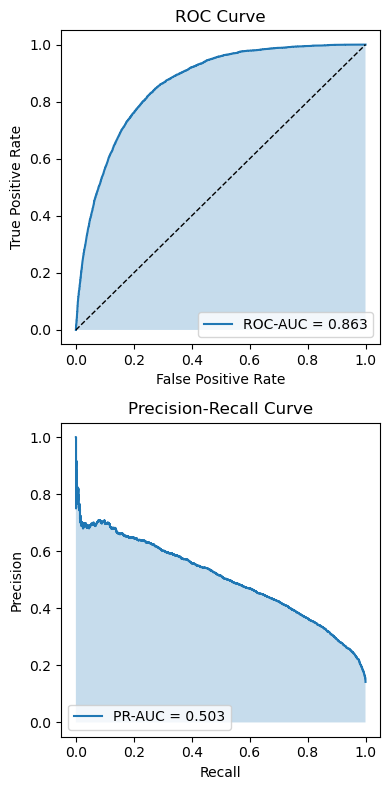

In [19]:
# Calculate the curve coordinates first
fpr, tpr, _     = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

# set the figure size and position
fig, axes = plt.subplots(2, 1, figsize=(4,8))

# ROC-AUC
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
# fill below the curve
axes[0].fill_between(fpr, tpr, alpha=0.25)
axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")

# PR-AUC
axes[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].fill_between(recall, precision, alpha=0.25)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

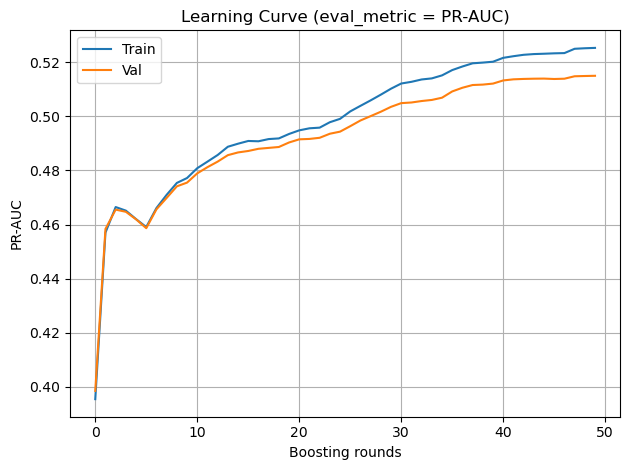

In [20]:
best_params = grid.best_params_

# best_params = {k: v for k, v in grid.best_params_.items()}

# construct the best model basend on the best parameters
best_xgb = xgb.XGBClassifier(
    **best_params,              
    enable_categorical=True,   
    eval_metric='aucpr',
    random_state=42
)

eval_set = [(X_train, y_train), (X_test, y_test)]
best_xgb.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False # do not print the evaluation results during training
)

results = best_xgb.evals_result()

# get the number of boosting rounds
epochs  = len(results['validation_0']['aucpr'])

# plot the learning curve
plt.plot(range(epochs), results['validation_0']['aucpr'], label='Train')
plt.plot(range(epochs), results['validation_1']['aucpr'], label='Val')
plt.xlabel("Boosting rounds")
plt.ylabel("PR-AUC")
plt.title("Learning Curve (eval_metric = PR-AUC)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


### Normalized BIM

In [21]:
X_bmi_weight.head()

,Smoker,HeartDiseaseorAttack,GeneralHealth,Mental (days),Sex,Age,Education,Income,BloodPressure,Cholesterol,Alcoholic,bmi_group_10
0,No,No,Very Good,10.81,Female,63.00,High school graduate,73106,Yes,Yes,No,1.66
1,Yes,No,Good,6.90,Female,54.00,College graduate,22322,No,No,No,1.82
2,No,No,Poor,30.00,Male,50.81,High school graduate,29097,Yes,Yes,No,1.66
3,Yes,No,Good,13.23,Male,74.00,Some high school,55498,Yes,No,No,1.00
4,Yes,No,Very Good,9.71,Female,62.08,Some college,15629,Yes,No,No,1.82


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bmi_weight, y, test_size=0.2, stratify=y, random_state=42
)

In [23]:
# Create the parameter grid
gbm_param_grid = {
    'eta': [0.01, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [10, 50],
    'colsample_bytree': [0.5, 0.8, 1],
    'subsample': [0.5, 0.8, 1.0]
}

# Instantiate the xgboost classifier
gbm = xgb.XGBClassifier(enable_categorical=True, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())


scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'neg_log_loss': 'neg_log_loss',
    'pr_auc': 'average_precision',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall'
}

# define cross-validation
# StratifiedKFold: stratified sampling 
# random_state = 42: for reproducibility
# n_splits=5: 5-fold
# n_repeats=2: repeat CV 2 times
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

# Create the GridSearchCV object
grid = GridSearchCV(estimator=gbm, 
                    param_grid=gbm_param_grid, 
                    cv=cv, scoring=scoring, 
                    verbose=1,
                    refit='pr_auc') # refit the best model using the 'pr_auc' score)

# # Fit the model
grid.fit(X_train, y_train)

Fitting 10 folds for each of 72 candidates, totalling 720 fits


GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=2, n_splits=5, random_state=42),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow...
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.5, 0.8, 1], 'eta': [0.01, 0.1],
                         'max_depth': [3, 5], 'n_estimators': [10, 50],
                         'subsample': [0.5, 0.8, 1.0]},
             refit='pr_auc',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'neg_log_loss': 'neg_log_loss',
                      'pr_auc': 'average_precision', 'precision': 'precision',
                      'recall': 'recall', 'roc_auc': 'roc_auc'},
             verbose=1)

In [24]:
best_model = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_

print("Best Parameters:", best_params)
print("Best PR AUC Score:", best_score)

# predict on the test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Classification report:\n", classification_report(y_test, y_pred, digits=3))
print("ROC AUC on test dataset:", roc_auc_score(y_test, y_prob))
print("PR AUC on test dataset:", average_precision_score(y_test, y_prob))


Best Parameters: {'colsample_bytree': 1, 'eta': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
Best PR AUC Score: 0.4559678122316243
Classification report:
               precision    recall  f1-score   support

           0      0.956     0.729     0.827     34072
           1      0.327     0.795     0.464      5644

    accuracy                          0.738     39716
   macro avg      0.641     0.762     0.645     39716
weighted avg      0.866     0.738     0.775     39716

ROC AUC on test dataset: 0.8425649833911562
PR AUC on test dataset: 0.45983847670729894


## SMOTE

In [25]:
df_smote = df.copy()

In [26]:
df_smote['GeneralHealth'] = pd.Categorical(
    df_smote['GeneralHealth'],
    categories=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
    ordered=True
)

df_smote['Education'] = pd.Categorical(
    df_smote['Education'],
    categories=[
        'Never attended school',
        'Elementary',
        'Some high school',
        'High school graduate',
        'Some college',
        'College graduate'
    ],
    ordered=True
)

df_smote['Smoker'] = pd.Categorical(df_smote['Smoker'])
df_smote['HeartDiseaseorAttack'] = pd.Categorical(df_smote['HeartDiseaseorAttack'])
df_smote['Sex'] = pd.Categorical(df_smote['Sex'])
df_smote['BloodPressure'] = pd.Categorical(df_smote['BloodPressure'])
df_smote['Cholesterol'] = pd.Categorical(df_smote['Cholesterol'])
df_smote['Alcoholic'] = pd.Categorical(df_smote['Alcoholic'])


In [27]:
df_smote.head()

,BMI,Smoker,HeartDiseaseorAttack,GeneralHealth,Mental (days),Sex,Age,Education,Income,Diabetes,BloodPressure,Cholesterol,Alcoholic,bmi_group_10
0,40.00,No,No,Very Good,10.81,Female,63.00,High school graduate,73106,No,Yes,Yes,No,1.66
1,25.00,Yes,No,Good,6.90,Female,54.00,College graduate,22322,No,No,No,No,1.82
2,33.58,No,No,Poor,30.00,Male,50.81,High school graduate,29097,No,Yes,Yes,No,1.66
3,27.00,Yes,No,Good,13.23,Male,74.00,Some high school,55498,No,Yes,No,No,1.00
4,24.00,Yes,No,Very Good,9.71,Female,62.08,Some college,15629,No,Yes,No,No,1.82


In [28]:
# Mapping for Diabetes
diabetes_mapping = {
    'No': 0, 
    'Diabetes': 1
}
df_smote['Diabetes'] = df_smote['Diabetes'].map(diabetes_mapping)

# One-hot encoding for Sex
df_smote = pd.get_dummies(df_smote, columns=['Sex'])

# Convert remaining categorical variables with "Yes" and "No" values to binary format for correlation computation
binary_columns = ['Smoker', 'HeartDiseaseorAttack', 'BloodPressure', 'Cholesterol', 'Alcoholic']

for column in binary_columns:
    df_smote[column] = df_smote[column].map({'Yes': 1, 'No': 0})
    
# Ordinal encoding for General_Health, Age_Category,BMI_Category
general_health_mapping = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Very Good': 3,
    'Excellent': 4
}
df_smote['GeneralHealth'] = df_smote['GeneralHealth'].map(general_health_mapping)

education_mapping = {
    'Never attended school': 0,
    'Elementary'           : 1,
    'Some high school'     : 2,
    'High school graduate' : 3,
    'Some college'         : 4,
    'College graduate'     : 5
}
df_smote['Education'] = df_smote['Education'].map(education_mapping)


In [29]:
# original bmi group VS bmi_weight group
# X_bmi_weight = df_smote.drop(['Diabetes', 'BMI'], axis=1)
X = df_smote.drop(['Diabetes', 'bmi_group_10'], axis=1)

y = df_smote['Diabetes']


In [31]:
X.head()

,BMI,Smoker,HeartDiseaseorAttack,GeneralHealth,Mental (days),Age,Education,Income,BloodPressure,Cholesterol,Alcoholic,Sex_Female,Sex_Male
0,40.00,0,0,3,10.81,63.00,3,73106,1,1,0,True,False
1,25.00,1,0,2,6.90,54.00,5,22322,0,0,0,True,False
2,33.58,0,0,0,30.00,50.81,3,29097,1,1,0,False,True
3,27.00,1,0,2,13.23,74.00,2,55498,1,0,0,False,True
4,24.00,1,0,3,9.71,62.08,4,15629,1,0,0,True,False


In [32]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# definr the resampling method
 # resampling strategy is set to 'minority' to resample the minority class
resampling = SMOTE(sampling_strategy='minority',random_state=42)

# define the model
xgb_cl = xgb.XGBClassifier(
    random_state=42,
    # class imbalance tuning
    scale_pos_weight=sum(y_train==0)/sum(y_train==1),
    eval_metric='logloss', 
)

# Define the pipeline
pipeline = Pipeline(
    steps=[
        # MinMaxScaler: scale the features to [0, 1]
        ('scale', MinMaxScaler()),
        # SMOTE: oversample the minority class
        ('smote', resampling),
        # ('tomek', TomekLinks(sampling_strategy='majority', random_state=42)),
        ('xgb_cl', xgb_cl)
    ],
    # cache the scale+resample results, 
    memory='cache_dir' # cache_dir is a directory to store the cached results
)

# Define scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    # 'neg_log_loss': 'neg_log_loss',
    'pr_auc': 'average_precision',
    # 'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall'
}

# cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# define parameter grid
gbm_param_grid = {
    'xgb_cl__eta': [0.01, 0.1],
    'xgb_cl__max_depth': [5, 7],
    'xgb_cl__n_estimators': [10, 50],
    'xgb_cl__colsample_bytree': [0.5, 0.8, 1.0],
    'xgb_cl__subsample': [0.5, 0.8, 1.0]
}


# Run GridSearchCV
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=gbm_param_grid,
    scoring=scoring,
    refit='pr_auc',
    cv=cv,
    verbose=1, # verbose=1: show the progress
    n_jobs=-1 # use all available CPU cores -> speed up the process
)

grid.fit(X_train, y_train)



Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(memory='cache_dir',
                                steps=[('scale', MinMaxScaler()),
                                       ('smote',
                                        SMOTE(random_state=42,
                                              sampling_strategy='minority')),
                                       ('xgb_cl',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=Non...
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb_cl__colsample_bytree': [0.5, 0.8, 1.0],
                         'xgb_cl__eta': [0.01, 0.1],
                         'xgb_cl__max_depth': [5, 7],
                         'xgb_cl__n_estimators': [10, 50],
                         'xgb_cl__subsample': [0.5, 0.8, 1.0]},
             refit='pr_auc',
             scoring={'f1': 'f1', 'pr_auc': 'average_precision',
                      'precision': 'precision', 'recall': 'recall',
                      'roc_auc': 'roc_auc'},
             verbose=1)

In [33]:
# predict on the test set
best_model = grid.best_estimator_
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

In [34]:
print("Best Parameters:", grid.best_params_)
print("Test Set Classification Report:\n", classification_report(y_test, y_test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("Test PR AUC:", average_precision_score(y_test, y_test_prob))

Best Parameters: {'xgb_cl__colsample_bytree': 1.0, 'xgb_cl__eta': 0.1, 'xgb_cl__max_depth': 7, 'xgb_cl__n_estimators': 50, 'xgb_cl__subsample': 0.8}
Test Set Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.48      0.65     34072
           1       0.23      0.94      0.37      5644

    accuracy                           0.55     39716
   macro avg       0.61      0.71      0.51     39716
weighted avg       0.87      0.55      0.61     39716

Test ROC AUC: 0.8373677618988031
Test PR AUC: 0.497100877486689


## =============== End of XGBoost xiwu3008 ===============

# ========= End of Individual Component ==========

# Group Component 2:

## Optimal Model Comparison:

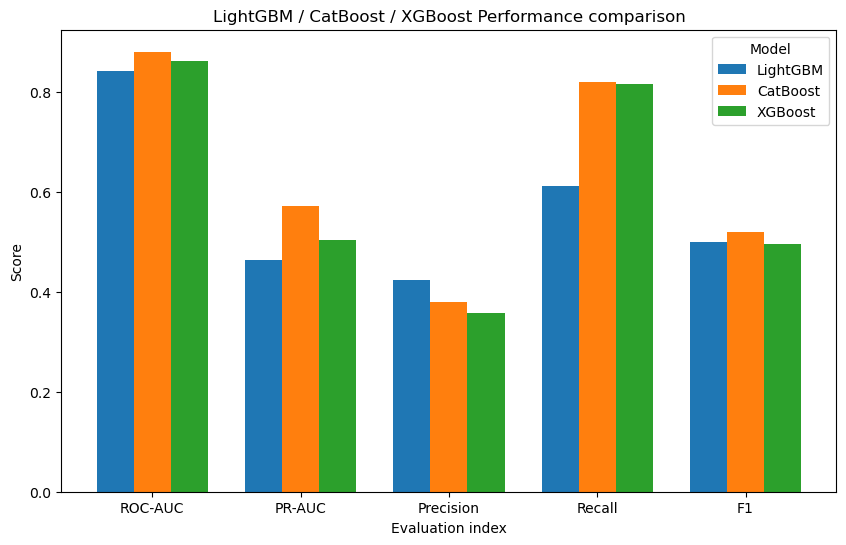

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Construct performance indicators that include all metrics DataFrame
data = {
    'Model': ['LightGBM', 'CatBoost', 'XGBoost'],
    'ROC-AUC':    [0.8420, 0.8811, 0.8633],
    'PR-AUC':     [0.4634, 0.5714, 0.5032],
    'Precision_1':[0.423,  0.380,  0.357],   # Class 1 precision
    'Recall_1':   [0.613,  0.820,  0.817],   # Class 1 recall
    'F1_1':       [0.501,  0.520,  0.497]    # Class 1 F1
}

df = pd.DataFrame(data)

# Draw the grouped bar charts of each indicator in the same figure
metrics = ['ROC-AUC', 'PR-AUC', 'Precision_1', 'Recall_1', 'F1_1']
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))
for i, model in enumerate(df['Model']):
    values = df.loc[df['Model'] == model, metrics].values.flatten()
    plt.bar(x + i * width, values, width, label=model)

plt.xticks(x + width, ['ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F1'])
plt.xlabel('Evaluation index')
plt.ylabel('Score')
plt.title('LightGBM / CatBoost / XGBoost Performance comparison')
plt.legend(title='Model')
plt.show()


## Final Model Recommendation:

In [36]:
total_data = {
    'Model': ['LightGBM', 'CatBoost', 'XGBoost'],
    'ROC-AUC': [0.8420, 0.8811, 0.8633],
    'PR-AUC': [0.4634, 0.5714, 0.5032],
    'Precision_0': [0.931, 0.960, 0.961],
    'Recall_0': [0.862, 0.780, 0.756],
    'F1_0': [0.895, 0.860, 0.847],
    'Precision_1': [0.423, 0.380, 0.357],
    'Recall_1': [0.613, 0.820, 0.817],
    'F1_1': [0.501, 0.520, 0.497]
}

df = pd.DataFrame(total_data)

from IPython.display import display; 
display(df)

,Model,ROC-AUC,PR-AUC,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1
0,LightGBM,0.84,0.46,0.93,0.86,0.90,0.42,0.61,0.50
1,CatBoost,0.88,0.57,0.96,0.78,0.86,0.38,0.82,0.52
2,XGBoost,0.86,0.50,0.96,0.76,0.85,0.36,0.82,0.50


#### Based on the performance comparison of the above models, for the diabetes dataset, among LightGBM, CatBoost, and XGBoost, the most suitable model we ultimately recommend is CatBoost. Its ROC-AUC is 0.8811, PR-AUC is 0.5714, the precision of class 0 is 0.96, the recall is 0.78, and the f1 score is 0.86. The precision of class 1 is 0.38, the recall is 0.82, and the f1 score is 0.52.

# ========== End of Group Component 2 ===========